# **📌 Twitter Entity Sentiment Analysis using NLP & Machine Learning**

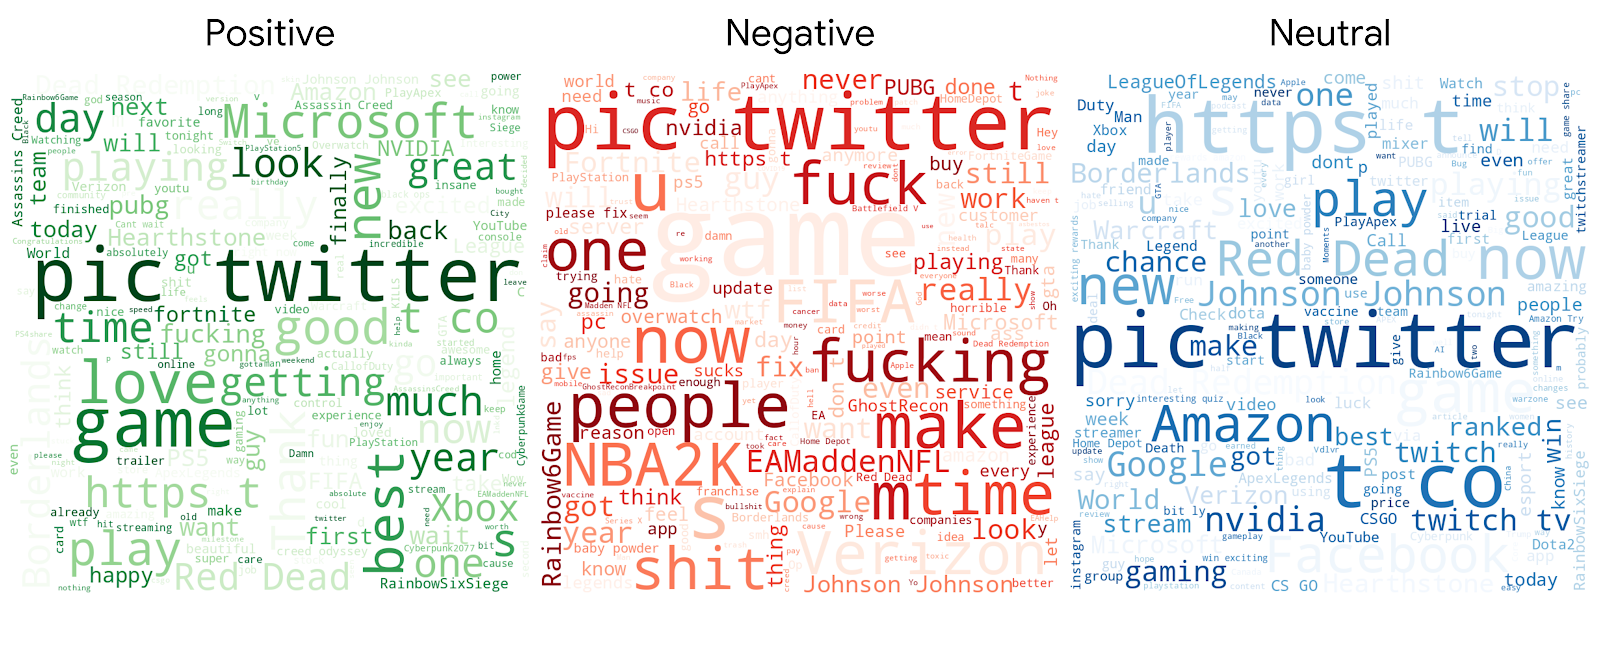

 # **About the Project**
 This project focuses on Natural Language Processing (NLP) and supervised machine learning classification to analyze sentiment expressed in Twitter data related to various entities such as companies and gaming titles.

# **Key Objective**

🔸 **Sentiment Classification**

The primary objective is to classify each tweet into one of four sentiment categories:
Positive, Negative, Neutral, or Irrelevant using machine learning models.

🔸 **Entity-Specific Sentiment Analysis**

The dataset contains tweets related to multiple entities including Amazon, Microsoft, Google, Facebook, CS-GO, Borderlands, and others.
The goal was to analyze sentiment patterns and understand public perception across different entities.

🔹 **Methodology**

The project follows a standard end-to-end NLP workflow:


🔸 **Data Loading & Inspection**

Loaded the twitter_validation.csv dataset containing columns such as ID, Entity (Media), Target (Sentiment), and Text.

Performed initial data inspection to check for missing values and class distribution.

🔸 **Text Preprocessing**

Applied text cleaning using regular expressions (re).

Performed tokenization and normalization using NLTK.

Removed stopwords and unnecessary characters.

Converted textual data into numerical features suitable for model training.

🔸 **Feature Engineering**

Transformed unstructured tweet text into structured numerical representations for machine learning input.

🔸 **Model Training & Evaluation**

Trained multiple classification models including:

*   Random Forest Classifier
*   KNeighborsClassifier


*   Decision Tree Classifier
*   naive_bayes


Evaluated models using performance metrics such as accuracy score.

# **Importing Essential Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re


# **Loading Data**

In [2]:
df_train = pd.read_csv('twitter_validation.csv', encoding='ISO-8859-1', header=None)
df_train.columns=['Id','Media','Target','Text']
df_train

,Id,Media,Target,Text
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...
...,...,...,...,...
995,4891,GrandTheftAuto(GTA),Irrelevant,â­ï¸ Toronto is the arts and culture capital...
996,4359,CS-GO,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
997,2652,Borderlands,Positive,Today sucked so itâs time to drink wine n pl...
998,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.


**first five values**

In [3]:
df_train.head()

,Id,Media,Target,Text
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


**last five values**

In [4]:
df_train.tail()

,Id,Media,Target,Text
995,4891,GrandTheftAuto(GTA),Irrelevant,â­ï¸ Toronto is the arts and culture capital...
996,4359,CS-GO,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
997,2652,Borderlands,Positive,Today sucked so itâs time to drink wine n pl...
998,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.
999,6960,johnson&johnson,Neutral,Johnson & Johnson to stop selling talc baby po...


**Data Information**

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Id      1000 non-null   int64 
 1   Media   1000 non-null   object
 2   Target  1000 non-null   object
 3   Text    1000 non-null   object
dtypes: int64(1), object(3)
memory usage: 31.4+ KB


**Columns Of Dataset**

In [6]:
df_train.columns

Index(['Id', 'Media', 'Target', 'Text'], dtype='object')

**Data type of each columns**

In [7]:
df_train.dtypes

Id         int64
Media     object
Target    object
Text      object
dtype: object

**Checking whether any missing values**

In [8]:
df_train.isna().sum()

Id        0
Media     0
Target    0
Text      0
dtype: int64

In [9]:
df_train['Target'].value_counts()

Target
Neutral       285
Positive      277
Negative      266
Irrelevant    172
Name: count, dtype: int64

# **Data Visualization**

<Axes: xlabel='Target', ylabel='count'>

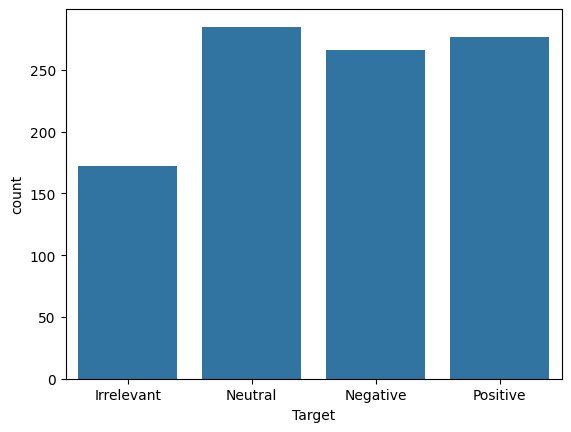

In [10]:
sns.countplot(x=df_train['Target'],data=df_train)


In [11]:
df_train['Media'].value_counts()

Media
RedDeadRedemption(RDR)               40
johnson&johnson                      39
PlayerUnknownsBattlegrounds(PUBG)    38
FIFA                                 38
LeagueOfLegends                      37
ApexLegends                          36
Nvidia                               35
TomClancysRainbowSix                 35
GrandTheftAuto(GTA)                  35
Amazon                               34
Fortnite                             34
PlayStation5(PS5)                    33
AssassinsCreed                       33
Borderlands                          33
Facebook                             33
Verizon                              32
Hearthstone                          32
Overwatch                            32
CS-GO                                32
CallOfDuty                           31
WorldOfCraft                         30
Cyberpunk2077                        30
MaddenNFL                            29
Microsoft                            28
Dota2                             

C:\Users\jinit\AppData\Local\Temp\ipykernel_36844\1303857233.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(),rotation=90,horizontalalignment='right',fontweight='light',fontsize='small')


[Text(0, 0, 'Facebook'),
 Text(1, 0, 'Amazon'),
 Text(2, 0, 'Microsoft'),
 Text(3, 0, 'CS-GO'),
 Text(4, 0, 'Google'),
 Text(5, 0, 'FIFA'),
 Text(6, 0, 'MaddenNFL'),
 Text(7, 0, 'TomClancysRainbowSix'),
 Text(8, 0, 'AssassinsCreed'),
 Text(9, 0, 'CallOfDuty'),
 Text(10, 0, 'Dota2'),
 Text(11, 0, 'Verizon'),
 Text(12, 0, 'NBA2K'),
 Text(13, 0, 'Nvidia'),
 Text(14, 0, 'GrandTheftAuto(GTA)'),
 Text(15, 0, 'RedDeadRedemption(RDR)'),
 Text(16, 0, 'Hearthstone'),
 Text(17, 0, 'ApexLegends'),
 Text(18, 0, 'Overwatch'),
 Text(19, 0, 'PlayerUnknownsBattlegrounds(PUBG)'),
 Text(20, 0, 'Borderlands'),
 Text(21, 0, 'PlayStation5(PS5)'),
 Text(22, 0, 'johnson&johnson'),
 Text(23, 0, 'Fortnite'),
 Text(24, 0, 'Xbox(Xseries)'),
 Text(25, 0, 'CallOfDutyBlackopsColdWar'),
 Text(26, 0, 'HomeDepot'),
 Text(27, 0, 'Cyberpunk2077'),
 Text(28, 0, 'TomClancysGhostRecon'),
 Text(29, 0, 'WorldOfCraft'),
 Text(30, 0, 'LeagueOfLegends'),
 Text(31, 0, 'Battlefield')]

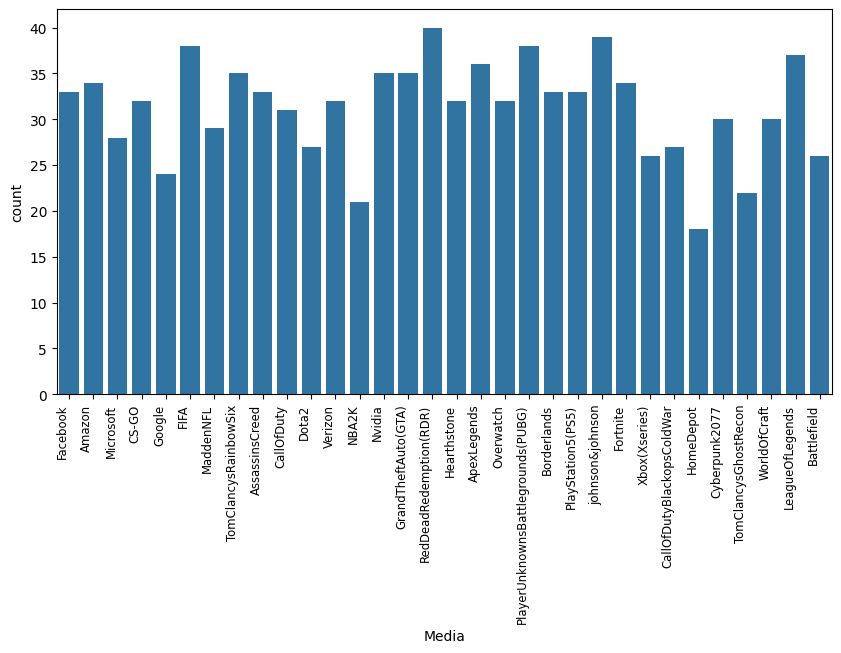

In [12]:
plt.figure(figsize=(10,5))
chart=sns.countplot(x=df_train['Media'],data=df_train)
chart.set_xticklabels(chart.get_xticklabels(),rotation=90,horizontalalignment='right',fontweight='light',fontsize='small')


# **Data Correlation**

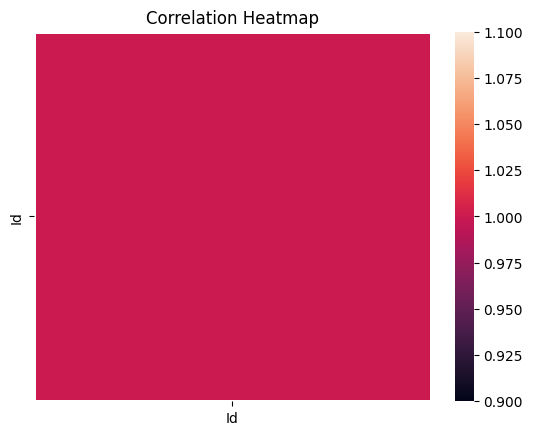

In [14]:
numeric_df = df_train.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, linewidths=1)
plt.title('Correlation Heatmap')
plt.show()


In [15]:
df_train.drop(df_train.index[(df_train['Target']=='Irrelevant')],axis=0,inplace=True)

In [16]:
df_train['Target'].unique()

array(['Neutral', 'Negative', 'Positive'], dtype=object)

In [17]:
df_train.reset_index(drop=True,inplace=True)


In [18]:
df_train.drop(['Id','Media'],axis=1,inplace=True)

In [19]:
df_train['Target']=df_train['Target'].map({'Positive':1,'Negative':-1,'Neutral':0})


In [20]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jinit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jinit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jinit\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\jinit\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [21]:
tweet=df_train.Text
tweet

0      BBC News - Amazon boss Jeff Bezos rejects clai...
1      @Microsoft Why do I pay for WORD when it funct...
2      CSGO matchmaking is so full of closet hacking,...
3      Now the President is slapping Americans in the...
4      Hi @EAHelp Iâve had Madeleine McCann in my c...
                             ...                        
823    Please explain how this is possible! How can t...
824    Good on Sony. As much as I want to see the new...
825    Today sucked so itâs time to drink wine n pl...
826    Bought a fraction of Microsoft today. Small wins.
827    Johnson & Johnson to stop selling talc baby po...
Name: Text, Length: 828, dtype: object

# **Tokenization**

In [22]:
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jinit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [27]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jinit\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jinit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [28]:
import nltk

nltk.download('punkt', download_dir='C:/nltk_data')

nltk.data.path.append('C:/nltk_data')


[nltk_data] Downloading package punkt to C:/nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


In [29]:
from nltk import TweetTokenizer
tk=TweetTokenizer()


In [30]:
tweet=tweet.apply(lambda x:tk.tokenize(x)).apply(lambda x:" ".join(x))
tweet


0      BBC News - Amazon boss Jeff Bezos rejects clai...
1      @Microsoft Why do I pay for WORD when it funct...
2      CSGO matchmaking is so full of closet hacking ...
3      Now the President is slapping Americans in the...
4      Hi @EAHelp Iâ   ve had Madeleine McCann in m...
                             ...                        
823    Please explain how this is possible ! How can ...
824    Good on Sony . As much as I want to see the ne...
825    Today sucked so itâ   s time to drink wine n...
826    Bought a fraction of Microsoft today . Small w...
827    Johnson & Johnson to stop selling talc baby po...
Name: Text, Length: 828, dtype: object

**To remove special characters**

In [31]:
tweet=tweet.str.replace('[^a-zA-Z0-9]+',' ')
tweet

0      BBC News - Amazon boss Jeff Bezos rejects clai...
1      @Microsoft Why do I pay for WORD when it funct...
2      CSGO matchmaking is so full of closet hacking ...
3      Now the President is slapping Americans in the...
4      Hi @EAHelp Iâ   ve had Madeleine McCann in m...
                             ...                        
823    Please explain how this is possible ! How can ...
824    Good on Sony . As much as I want to see the ne...
825    Today sucked so itâ   s time to drink wine n...
826    Bought a fraction of Microsoft today . Small w...
827    Johnson & Johnson to stop selling talc baby po...
Name: Text, Length: 828, dtype: object

In [32]:
from nltk.tokenize import word_tokenize
tweet=tweet.apply(lambda x:" ".join([w for w in word_tokenize(x) if len(w)>=3]))
tweet

0      BBC News Amazon boss Jeff Bezos rejects claims...
1      Microsoft Why pay for WORD when functions poor...
2      CSGO matchmaking full closet hacking truly awf...
3      Now the President slapping Americans the face ...
4      EAHelp had Madeleine McCann cellar for the pas...
                             ...                        
823    Please explain how this possible How can they ...
824    Good Sony much want see the new PS5 what going...
825    Today sucked itâ time drink wine play borderla...
826           Bought fraction Microsoft today Small wins
827    Johnson Johnson stop selling talc baby powder ...
Name: Text, Length: 828, dtype: object

# **Stemming**

In [33]:
from nltk.stem import SnowballStemmer
stemmer=SnowballStemmer('english')
tweet=tweet.apply(lambda x:[stemmer.stem(i.lower()) for i in tk.tokenize(x)]).apply(lambda x:" ".join(x))
tweet

0      bbc news amazon boss jeff bezo reject claim co...
1      microsoft whi pay for word when function poor ...
2           csgo matchmak full closet hack truli aw game
3      now the presid slap american the face that rea...
4      eahelp had madelein mccann cellar for the past...
                             ...                        
823    pleas explain how this possibl how can they le...
824    good soni much want see the new ps5 what go ri...
825    today suck itâ time drink wine play borderland...
826            bought fraction microsoft today small win
827    johnson johnson stop sell talc babi powder and...
Name: Text, Length: 828, dtype: object

**To remove stopwords**

In [34]:
from nltk.corpus import stopwords
stop=stopwords.words('english')
tweet=tweet.apply(lambda x:[i for i in word_tokenize(x) if i not in stop]).apply(lambda x:" ".join(x))
tweet

0      bbc news amazon boss jeff bezo reject claim co...
1      microsoft whi pay word function poor samsungus...
2           csgo matchmak full closet hack truli aw game
3      presid slap american face realli commit unlaw ...
4      eahelp madelein mccann cellar past year littl ...
                             ...                        
823    pleas explain possibl let compani overcharg it...
824    good soni much want see new ps5 go right much ...
825    today suck itâ time drink wine play borderland...
826            bought fraction microsoft today small win
827    johnson johnson stop sell talc babi powder can...
Name: Text, Length: 828, dtype: object

# **Vectorization**

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
vec=TfidfVectorizer()
train_data=vec.fit_transform(tweet)


In [36]:
print(train_data)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10813 stored elements and shape (828, 3926)>
  Coords	Values
  (0, 490)	0.45745385846764186
  (0, 2331)	0.36769287800522604
  (0, 307)	0.14194559722850278
  (0, 589)	0.21878966952976298
  (0, 1855)	0.22872692923382093
  (0, 522)	0.24273271014976627
  (0, 2843)	0.24273271014976627
  (0, 770)	0.1994591378361782
  (0, 826)	0.1649674497645602
  (0, 238)	0.2110817320771546
  (0, 2026)	0.12356149476428092
  (0, 1113)	0.22872692923382093
  (0, 979)	0.24273271014976627
  (0, 797)	0.11662982606902166
  (0, 3589)	0.21878966952976298
  (0, 427)	0.24273271014976627
  (0, 651)	0.24273271014976627
  (1, 2189)	0.24905209813650908
  (1, 3771)	0.26191944627409375
  (1, 2525)	0.31240246924634235
  (1, 3814)	0.36523945141691455
  (1, 1401)	0.4052090854499021
  (1, 2628)	0.3818283483730563
  (1, 2975)	0.4052090854499021
  (1, 760)	0.4052090854499021
  :	:
  (825, 3510)	0.3301211803226351
  (825, 814)	0.2436951267667636
  (825, 1616)	0.272862033

# **Seperating input and output labels**

In [37]:
x=train_data
y=df_train['Target'].values

# **Split train and test**

In [38]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42)


In [39]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=7)
from sklearn.naive_bayes import MultinomialNB
nb=MultinomialNB()
from sklearn.svm import SVC
svm=SVC()
from sklearn.tree import DecisionTreeClassifier
dc=DecisionTreeClassifier()
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
lst=[knn,nb,svm,dc,rf]
for i in lst:
  i.fit(x_train,y_train)
  y_pred=i.predict(x_test)
  print("Accuracy score of",i,accuracy_score(y_test,y_pred))
  print(confusion_matrix(y_test,y_pred))
  print(classification_report(y_test,y_pred))



Accuracy score of KNeighborsClassifier(n_neighbors=7) 0.4819277108433735
[[57 11 11]
 [37 31 11]
 [46 13 32]]
              precision    recall  f1-score   support

          -1       0.41      0.72      0.52        79
           0       0.56      0.39      0.46        79
           1       0.59      0.35      0.44        91

    accuracy                           0.48       249
   macro avg       0.52      0.49      0.47       249
weighted avg       0.52      0.48      0.47       249

Accuracy score of MultinomialNB() 0.5863453815261044
[[48 23  8]
 [15 45 19]
 [14 24 53]]
              precision    recall  f1-score   support

          -1       0.62      0.61      0.62        79
           0       0.49      0.57      0.53        79
           1       0.66      0.58      0.62        91

    accuracy                           0.59       249
   macro avg       0.59      0.59      0.59       249
weighted avg       0.60      0.59      0.59       249

Accuracy score of SVC() 0.582329317269

# **Conclusion**

For future implementations or real-time sentiment tracking of Twitter entities, the Random Forest model is recommended. It provides the best balance of precision and recall across all sentiment categories (Positive, Negative, Neutral, and Irrelevant).